# Learning rate experiment

In [10]:
# DATA_DIR = DATA_DIR

TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob("*.wav"))))
print("Valid:", len(list(VALID_DIR.rglob("*.wav"))))

Train: 51486
Valid: 6828


In [38]:
from pathlib import Path
import torch
import numpy as np
import random
import pandas as pd
import gc
import itertools

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from data.transforms import FeatureConfig

from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed

from plots import (
    plot_f1_training_curves,
    build_summary_df,
    plot_summary_table,
    plot_metrics_comparison,
    plot_f1_comparison,
    plot_confusion_matrix
)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


## MEL

In [12]:
train_ds, valid_ds, test_ds = get_datasets(
    data_format="mel",
    train_path=TRAIN_DIR,
    valid_path=VALID_DIR,
    test_path=TEST_DIR,
)

In [13]:
CACHE_DIR = Path("/kaggle/working/cache_hparams_mel")

precompute_features(train_ds, CACHE_DIR / "train")
precompute_features(valid_ds, CACHE_DIR / "valid")
precompute_features(test_ds, CACHE_DIR / "test")

train_ds_cached = CachedDataset(CACHE_DIR / "train")
valid_ds_cached = CachedDataset(CACHE_DIR / "valid")
test_ds_cached = CachedDataset(CACHE_DIR / "test")

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_hparams_mel/train


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache_hparams_mel/valid


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache_hparams_mel/test


In [ ]:
def cnn_transformer_factory(repr_name="mel", dropout=0.1):
    n_features = 40 if repr_name == "mfcc" else 64

    return CNNTransformer(
        n_features=n_features,
        n_timesteps=101,
        num_classes=12,
        base_channels=32,
        d_model=128,
        nhead=4,
        num_layers=4,
        dropout=dropout,
        pooling="mean",
    )

In [48]:
BATCH_SIZE = 256
DROPOUT = 0.0
SEEDS = [0, 1, 2]
EPOCHS = 30

In [49]:
LEARNING_RATES = [1e-4, 2e-4, 3e-4, 5e-4, 1e-3]

In [50]:
LR_SAVE_PATH = "/kaggle/working/lr_experiment.csv"

def learning_rate_experiment(lr_values, seeds=[0, 1, 2], epochs=30, batch_size=256, dropout=0.0):
    results = []

    for lr in lr_values:
        for seed in seeds:
            print(f"\nLR={lr} | seed={seed}")

            set_seed(seed)

            model = cnn_transformer_factory(
                repr_name="mel",
                dropout=dropout,
            ).to(device)

            model, history = train(
                model,
                train_ds_cached,
                valid_ds_cached,
                epochs=epochs,
                batch_size=batch_size,  # FIXED
                lr=lr,
                device=device,
            )

            results.append({
                "lr": lr,
                "seed": seed,
                "dropout": dropout,
                "batch_size": batch_size,
                "best_valid_acc": max(history["valid_acc"]),
                "best_valid_macro_f1": max(history["valid_f1"]),
            })

            pd.DataFrame(results).to_csv(LR_SAVE_PATH, index=False)

            del model
            torch.cuda.empty_cache()
            gc.collect()

    return pd.DataFrame(results)

In [51]:
df_lr = learning_rate_experiment(
    lr_values=LEARNING_RATES, 
    seeds=SEEDS, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
)


LR=0.0001 | seed=0
Epoch 1/30 | Train Loss: 1.0766 | Valid Loss: 0.5010 | Valid Acc: 0.8541 | Valid Macro F1: 0.7435
Epoch 2/30 | Train Loss: 0.3175 | Valid Loss: 0.2576 | Valid Acc: 0.9243 | Valid Macro F1: 0.8799
Epoch 3/30 | Train Loss: 0.1967 | Valid Loss: 0.2338 | Valid Acc: 0.9268 | Valid Macro F1: 0.8767
Epoch 4/30 | Train Loss: 0.1451 | Valid Loss: 0.1936 | Valid Acc: 0.9395 | Valid Macro F1: 0.8952
Epoch 5/30 | Train Loss: 0.1197 | Valid Loss: 0.1803 | Valid Acc: 0.9457 | Valid Macro F1: 0.9131
Epoch 6/30 | Train Loss: 0.1005 | Valid Loss: 0.1811 | Valid Acc: 0.9464 | Valid Macro F1: 0.9200
Epoch 7/30 | Train Loss: 0.0839 | Valid Loss: 0.1518 | Valid Acc: 0.9561 | Valid Macro F1: 0.9302
Epoch 8/30 | Train Loss: 0.0743 | Valid Loss: 0.1722 | Valid Acc: 0.9482 | Valid Macro F1: 0.9242
Epoch 9/30 | Train Loss: 0.0589 | Valid Loss: 0.1777 | Valid Acc: 0.9514 | Valid Macro F1: 0.9251
Epoch 10/30 | Train Loss: 0.0533 | Valid Loss: 0.1494 | Valid Acc: 0.9555 | Valid Macro F1: 0.9345

In [53]:
summary_lr = (
    df_lr.groupby("lr")
    .agg(
        mean_f1=("best_valid_macro_f1", "mean"),
        std_f1=("best_valid_macro_f1", "std"),
        mean_acc=("best_valid_acc", "mean"),
        std_acc=("best_valid_acc", "std"),
    )
    .reset_index()
)

summary_lr

,lr,mean_f1,std_f1,mean_acc,std_acc
0,0.0001,0.938807,0.002616,0.960164,0.002013
1,0.0002,0.947231,0.002331,0.965827,0.000592
2,0.0003,0.950830,0.001902,0.967389,0.000369
3,0.0005,0.951522,0.000801,0.968219,0.001251
4,0.0010,0.952917,0.002001,0.968951,0.000960


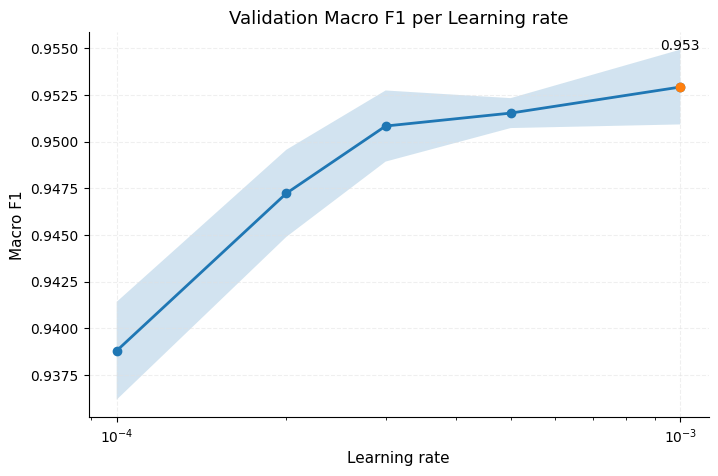

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 5))

x = summary_lr["lr"]
y = summary_lr["mean_f1"]
std = summary_lr["std_f1"]

plt.plot(x, y, marker="o", linewidth=2)
plt.fill_between(x, y - std, y + std, alpha=0.2)

best_idx = np.argmax(y)
plt.scatter(x.iloc[best_idx], y.iloc[best_idx], zorder=5)
plt.text(
    x.iloc[best_idx],
    y.iloc[best_idx] + 0.002,
    f"{y.iloc[best_idx]:.3f}",
    ha="center"
)

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1 per Learning rate")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

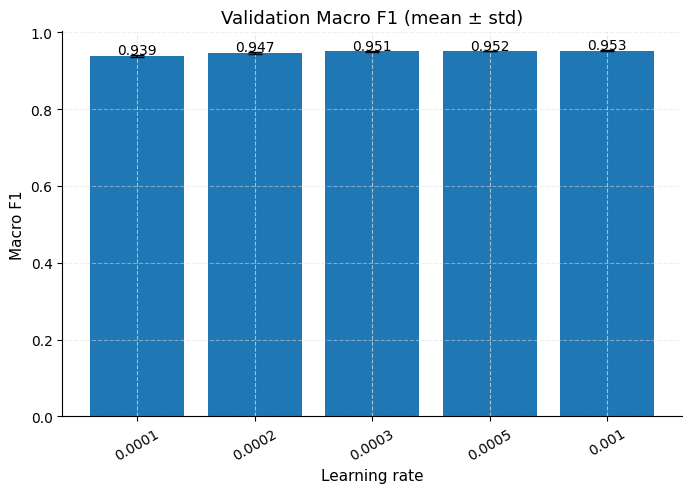

In [60]:
plt.figure(figsize=(8, 5))

x_pos = np.arange(len(summary_lr))

bars = plt.bar(
    x_pos,
    summary_lr["mean_f1"],
    yerr=summary_lr["std_f1"],
    capsize=5
)

plt.xticks(x_pos, [str(lr) for lr in summary_lr["lr"]], rotation=30)
plt.ylabel("Macro F1")
plt.xlabel("Learning rate")
plt.title("Validation Macro F1 (mean ± std)")

for i, (mean, std) in enumerate(zip(summary_lr["mean_f1"], summary_lr["std_f1"])):
    plt.text(i, mean + std + 0.002, f"{mean:.3f}", ha="center")

plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.show()

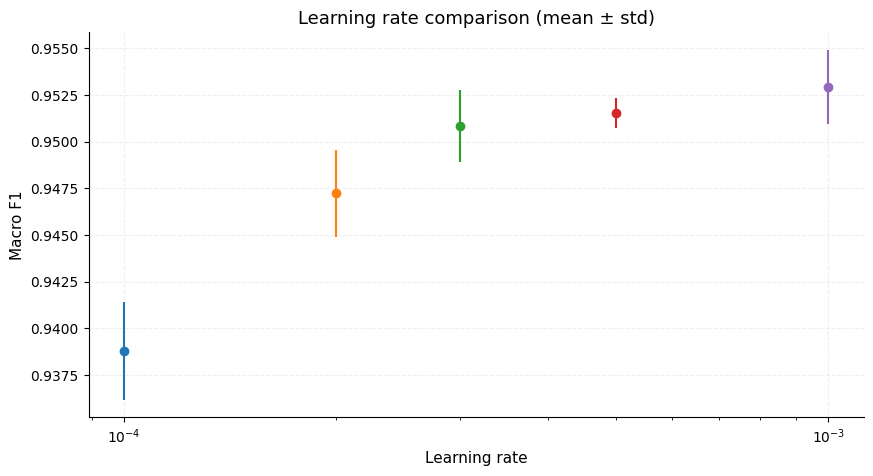

In [61]:
plt.figure(figsize=(10, 5))

for i, row in summary_lr.iterrows():
    plt.errorbar(
        [row["lr"]],
        [row["mean_f1"]],
        yerr=[row["std_f1"]],
        fmt="o",
        label=f"lr={row['lr']}"
    )

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Macro F1")
plt.title("Learning rate comparison (mean ± std)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()